# EDA ANALYSIS

In [2]:
import sys
print(sys.executable)

C:\Users\Admin\.virtualenvs\ai_customer_intelligence-q_Nzp0-8\Scripts\python.EXE


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
data=pd.read_csv("../Datasets/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [7]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Data Dimensions

In [8]:
data.shape

(7043, 21)

#### Data columns

In [9]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

#### Data Datatypes

In [10]:
data.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

#### Missing Values

In [12]:
missing_values=data.isnull().sum()
missing_values

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

#### Duplicate Values

In [14]:
duplicates=data.duplicated().sum()
duplicates

np.int64(0)

In [15]:
data["TotalCharges"].value_counts(dropna=False).tail()

TotalCharges
1990.5    1
7362.9    1
346.45    1
306.6     1
6844.5    1
Name: count, dtype: int64

In [16]:
data[data["TotalCharges"].astype(str).str.strip() == " "].shape

(0, 21)

In [17]:
data["TotalCharges"].astype(str).str.strip().eq("").sum()

np.int64(11)

In [18]:
pd.to_numeric(data["TotalCharges"], errors="coerce").isna().sum()

np.int64(11)

In [19]:
data.loc[
    data["TotalCharges"].astype(str).str.strip().eq(""),
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [20]:
data.loc[
    data["TotalCharges"].astype(str).str.strip().eq(""),
    "TotalCharges"
].tolist()

[' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ']

In [21]:
categorical_columns=data.select_dtypes(include="object").columns
for col in categorical_columns:
    print(f"\n{col}")
    print(data[col].unique())
    


customerID
<StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str

gender
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

Partner
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Dependents
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

PhoneService
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

MultipleLines
<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

InternetService
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

OnlineSecurity
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

OnlineBackup
<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

DeviceProtection
<StringArray>
['No', 'Yes', 'No internet service']


C:\Users\Admin\AppData\Local\Temp\ipykernel_15528\1335682706.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns=data.select_dtypes(include="object").columns


#### Statistical Summary

In [22]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [24]:
data.describe(include="object")

C:\Users\Admin\AppData\Local\Temp\ipykernel_15528\460854327.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.describe(include="object")


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


#### Churn Distribution

In [26]:
data["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [27]:
data["Churn"].value_counts(normalize=True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

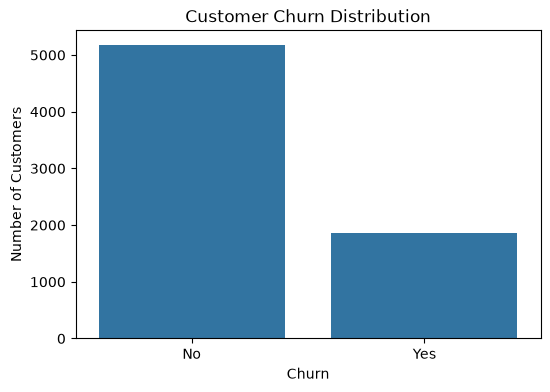

In [28]:
plt.figure(figsize=(6, 4))
sns.countplot(data=data, x="Churn")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

#### Contract Type

In [29]:
data["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [30]:
data["Contract"].value_counts(normalize=True)*100

Contract
Month-to-month    55.019168
Two year          24.066449
One year          20.914383
Name: proportion, dtype: float64

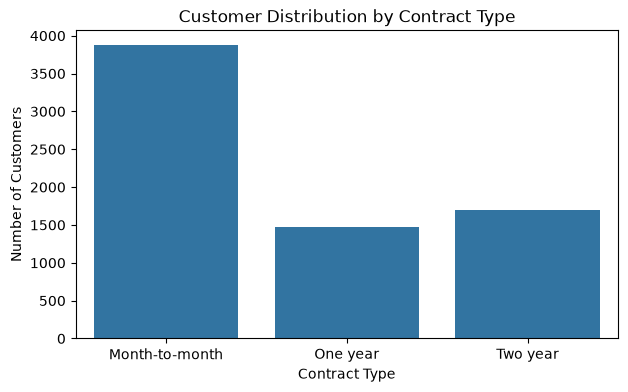

In [32]:
plt.figure(figsize=(7, 4))
sns.countplot(data=data, x="Contract")
plt.title("Customer Distribution by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.show()

#### Churn by contract

In [33]:
contract_churn = pd.crosstab(data["Contract"],data["Churn"])
contract_churn

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


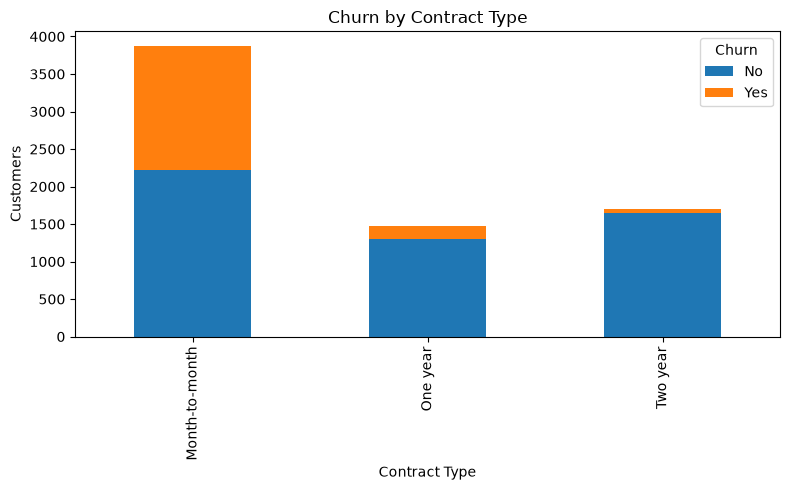

In [39]:
contract_churn.plot(kind="bar",stacked=True,figsize=(8, 5))
plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Customers")
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

#### Payment Method

In [40]:
data["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

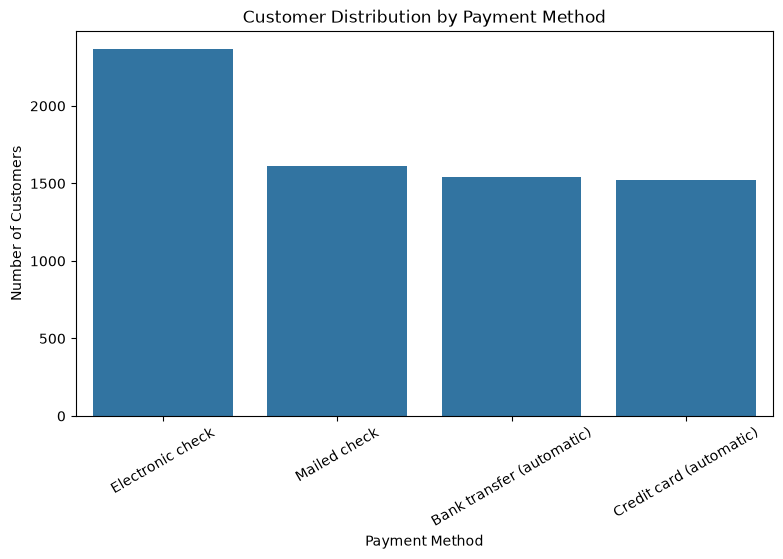

In [44]:
plt.figure(figsize=(9, 5))
sns.countplot(data=data,x="PaymentMethod")
plt.title("Customer Distribution by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)
plt.show()

In [45]:
payment_churn=pd.crosstab(data["PaymentMethod"],data["Churn"])
payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


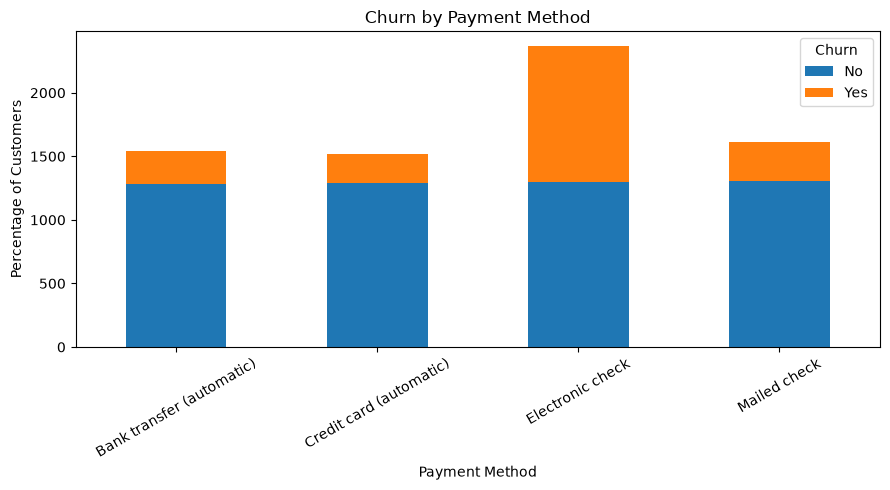

In [52]:
payment_churn.plot(kind="bar",stacked=True,figsize=(9, 5))
plt.title("Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=30)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

#### Internrt Service

In [48]:
data["InternetService"].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

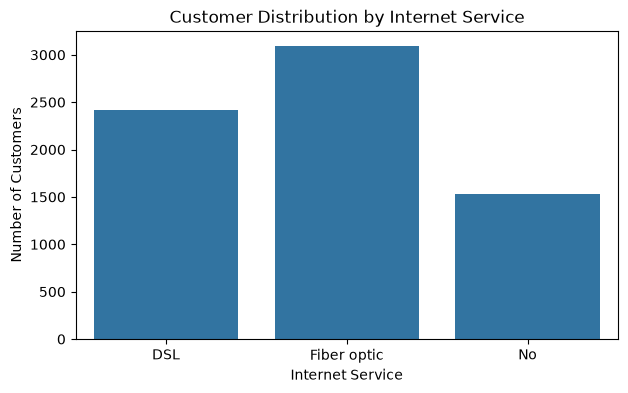

In [49]:
plt.figure(figsize=(7, 4))
sns.countplot(data=data,x="InternetService")
plt.title("Customer Distribution by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.show()

In [51]:
internet_churn=pd.crosstab(data["InternetService"],data["Churn"])
internet_churn

Churn,No,Yes
InternetService,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


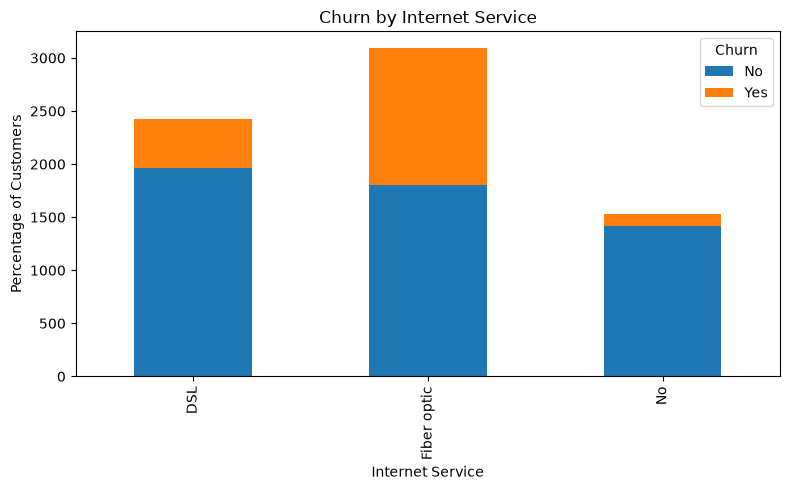

In [53]:
internet_churn.plot(kind="bar",stacked=True,figsize=(8, 5))
plt.title("Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Percentage of Customers")
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

#### Tenure

In [54]:
data["tenure"].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

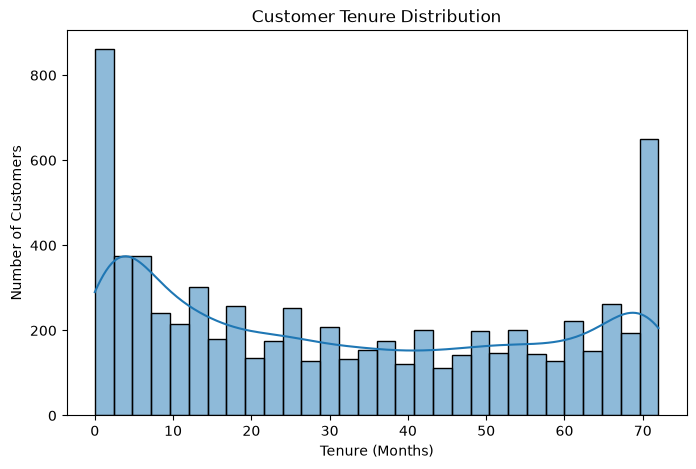

In [57]:
plt.figure(figsize=(8, 5))
sns.histplot(data=data,x="tenure",bins=30,kde=True)
plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.show()

In [61]:
tenure_bins = [0, 12, 24, 48, 72]
tenure_labels = ["0-12", "13-24", "25-48", "49-72"]
tenure_group = pd.cut(data["tenure"],bins=tenure_bins,labels=tenure_labels,include_lowest=True)
tenure_churn = pd.crosstab(tenure_group,data["Churn"])
tenure_churn

Churn,No,Yes
tenure,,
0-12,1149,1037
13-24,730,294
25-48,1269,325
49-72,2026,213


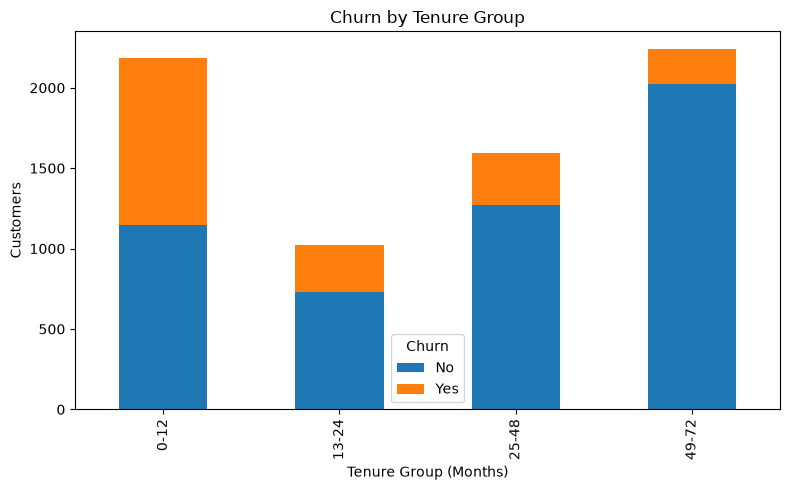

In [63]:
tenure_churn.plot(kind="bar",stacked=True,figsize=(8, 5))
plt.title("Churn by Tenure Group")
plt.xlabel("Tenure Group (Months)")
plt.ylabel("Customers")
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

#### Monthly charges

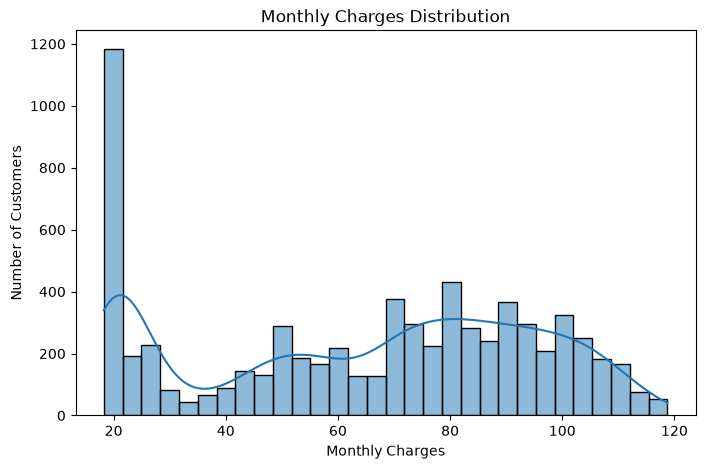

In [64]:
plt.figure(figsize=(8, 5))
sns.histplot(data=data,x="MonthlyCharges",bins=30,kde=True)
plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.show()

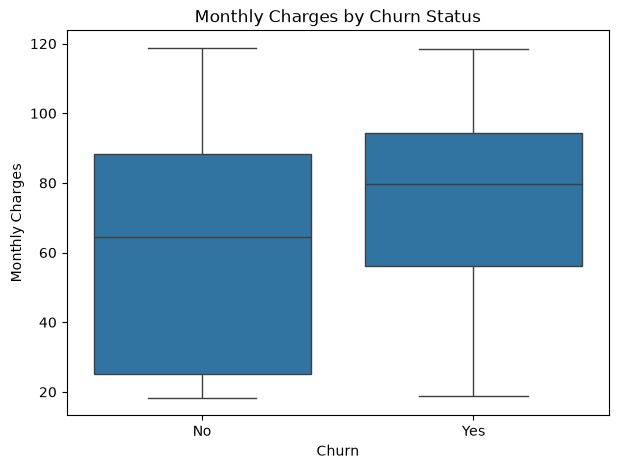

In [66]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=data,x="Churn",y="MonthlyCharges")
plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

#### Total charges

In [67]:
total_charges_numeric = pd.to_numeric(data["TotalCharges"],errors="coerce")

In [68]:
total_charges_numeric.describe()

count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64

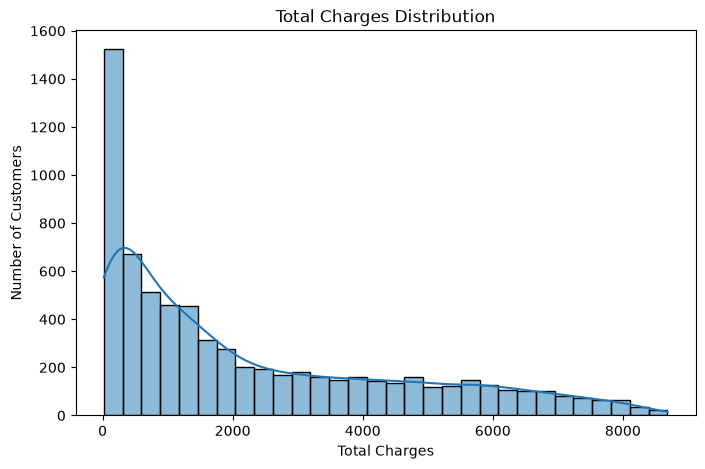

In [69]:
plt.figure(figsize=(8, 5))
sns.histplot(total_charges_numeric,bins=30,kde=True)
plt.title("Total Charges Distribution")
plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")
plt.show()

#### Demographics

In [73]:
demographic_columns = ["gender","Partner","Dependents","SeniorCitizen"]
for col in demographic_columns:
    print(f"\n{col}")
    print(data[col].value_counts())


gender
gender
Male      3555
Female    3488
Name: count, dtype: int64

Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

SeniorCitizen
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64


#### Service subscriptions

In [74]:
service_columns = [
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]
for col in service_columns:
    print(f"\n{col}")
    print(data[col].value_counts())


PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

OnlineSecurity
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

OnlineBackup
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

DeviceProtection
DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64

TechSupport
TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64

StreamingTV
StreamingTV
No                     2810
Yes                    2707
No internet service    1526
Name: c

#### Correlation between numerical columns

In [76]:
numeric_data=data[["SeniorCitizen", "tenure", "MonthlyCharges"]]
corr=numeric_data.corr()
corr

,SeniorCitizen,tenure,MonthlyCharges
SeniorCitizen,1.000000,0.016567,0.220173
tenure,0.016567,1.000000,0.247900
MonthlyCharges,0.220173,0.247900,1.000000


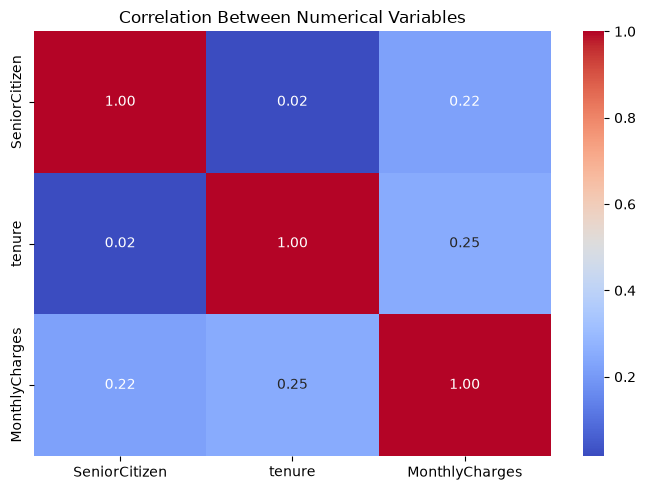

In [77]:
plt.figure(figsize=(7, 5))
sns.heatmap(corr,annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Between Numerical Variables")
plt.tight_layout()
plt.show()

#### Outliers

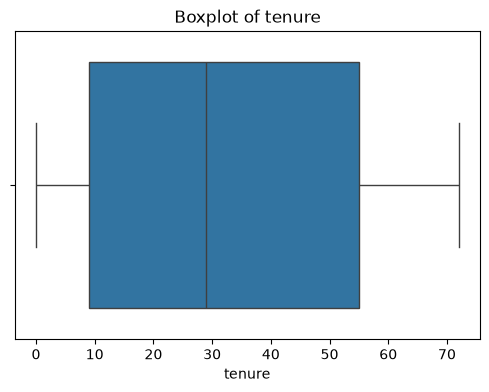

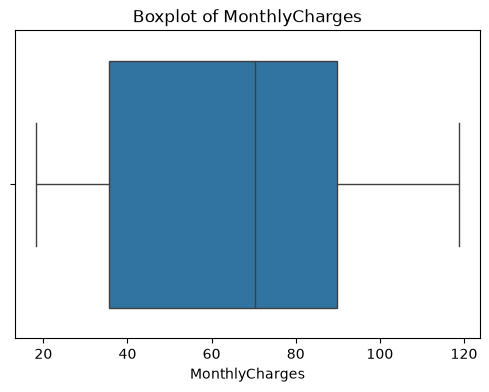

In [80]:
numeric_columns = ["tenure","MonthlyCharges"]

for col in numeric_columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=data[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

#### Categorical Feature Distribution

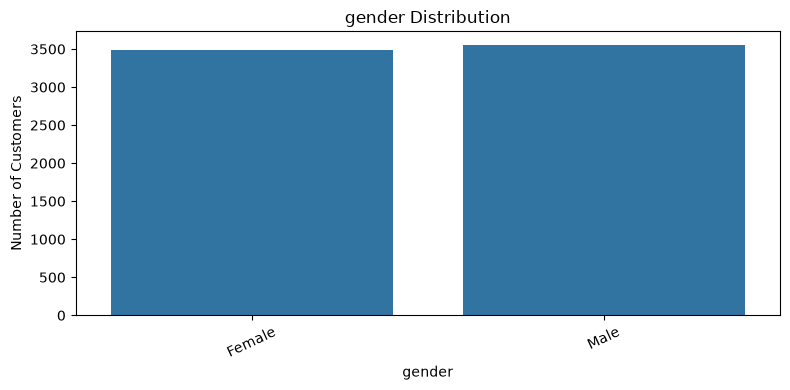

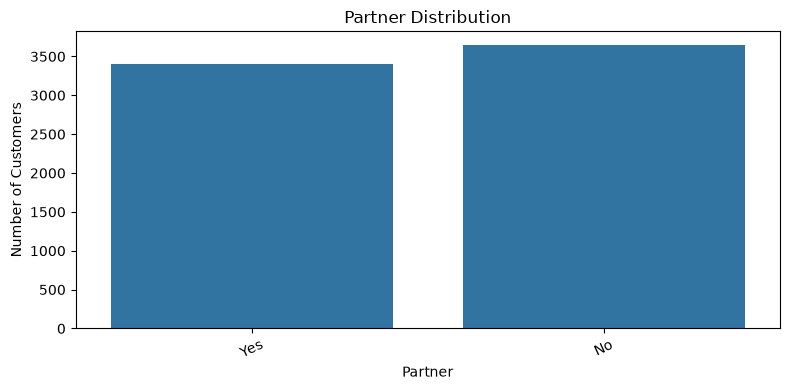

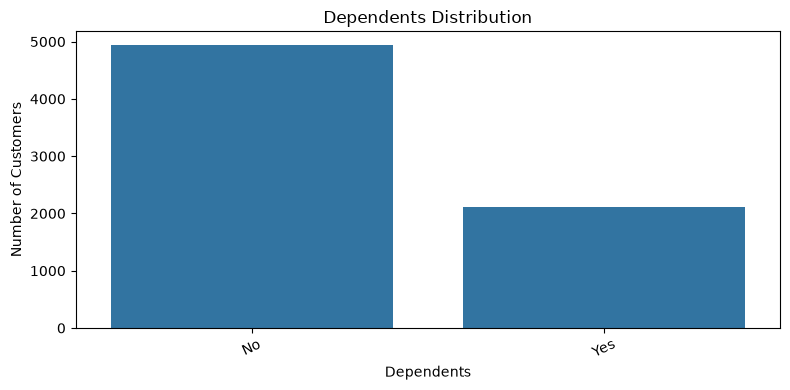

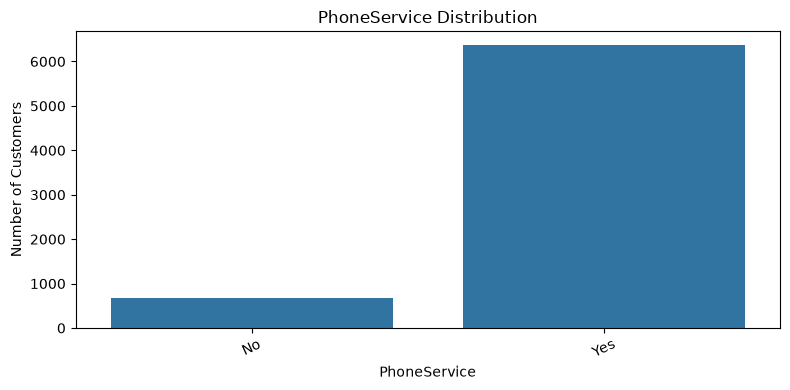

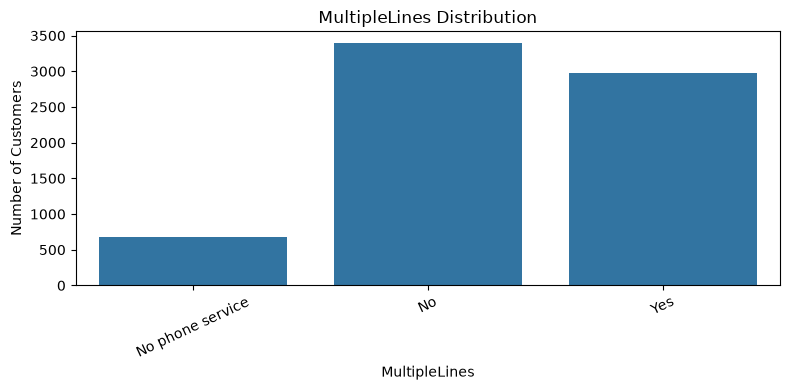

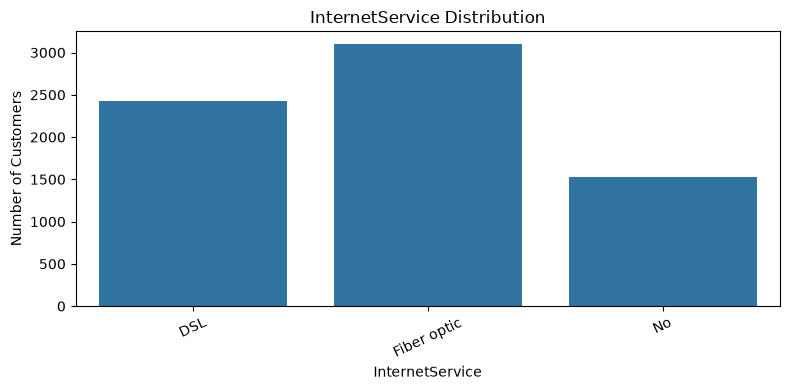

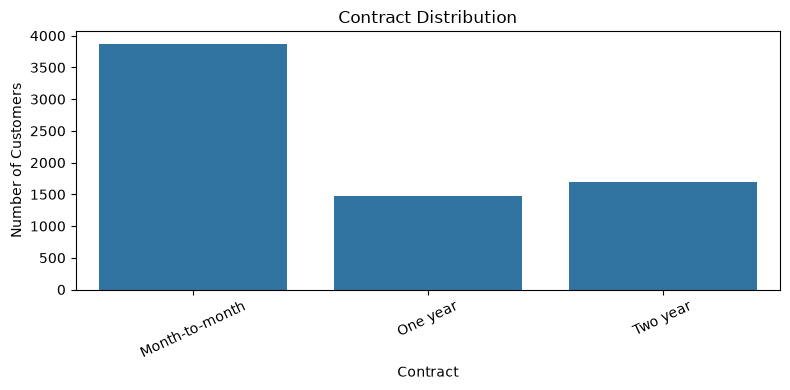

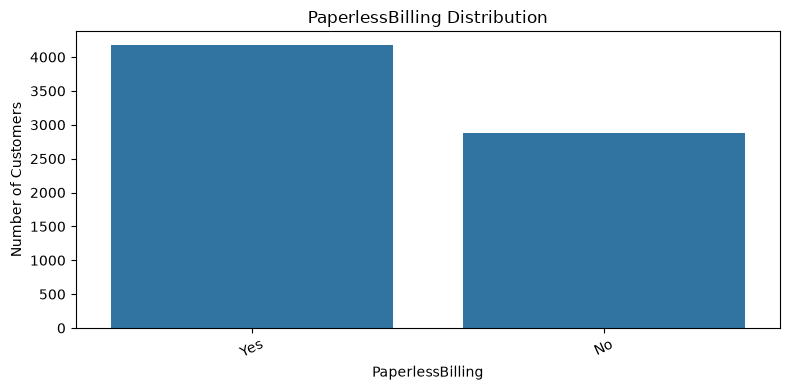

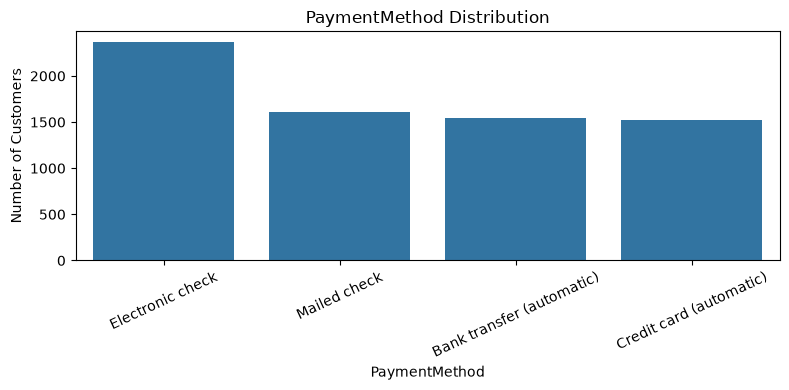

In [85]:
categorical_columns = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

for col in categorical_columns:
    plt.figure(figsize=(8, 4))
    
    sns.countplot(data=data, x=col)
    
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Number of Customers")
    
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.show()